# AI-Generated Image Detection using Vision Transformer (ViT)

This notebook trains a pretrained ViT model to classify images as Real or AI-Generated (Fake).

In [1]:
# Install required packages
import subprocess
import sys

packages = ['torch', 'torchvision', 'transformers', 'Pillow', 'matplotlib', 'scikit-learn', 'tqdm']

for package in packages:
    try:
        __import__(package)
        print(f"{package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} installed successfully")

torch already installed
torchvision already installed


C:\Users\AARAV AGGARWAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers already installed
Installing Pillow...
Pillow installed successfully
matplotlib already installed
Installing scikit-learn...
scikit-learn installed successfully
tqdm already installed


In [ ]:
# Fix numpy compatibility issue
import subprocess
import sys

print("Reinstalling numpy with compatible version...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "--force-reinstall", "numpy==1.26.4"])
print("Numpy reinstalled successfully. Please restart the kernel.")

Reinstalling numpy with compatible version...


In [2]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import ViTForImageClassification, ViTImageProcessor
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
from tqdm import tqdm
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Set paths
train_dir = './data/train'
test_dir = './data/test'

# Check data structure
print("Training data:")
for category in os.listdir(train_dir):
    path = os.path.join(train_dir, category)
    if os.path.isdir(path):
        num_images = len(os.listdir(path))
        print(f"  {category}: {num_images} images")

print("\nTest data:")
for category in os.listdir(test_dir):
    path = os.path.join(test_dir, category)
    if os.path.isdir(path):
        num_images = len(os.listdir(path))
        print(f"  {category}: {num_images} images")

Training data:
  FAKE: 50000 images
  REAL: 50000 images

Test data:
  FAKE: 10000 images
  REAL: 10000 images


In [4]:
# Load pretrained ViT model and processor
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

# Create model for binary classification (Real vs Fake)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "FAKE", 1: "REAL"},
    label2id={"FAKE": 0, "REAL": 1},
    ignore_mismatched_sizes=True
)

model = model.to(device)
print(f"Model loaded: {model_name}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Fetching 1 files: 100%|██████████| 1/1 [00:00<?, ?it/s]
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: google/vit-base-patch16-224
Number of parameters: 85,800,194


In [5]:
# Prepare data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Class mapping: {train_dataset.class_to_idx}")

Training samples: 100000
Test samples: 20000
Class mapping: {'FAKE': 0, 'REAL': 1}


In [6]:
# Training setup
num_epochs = 5
learning_rate = 2e-5

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Optimizer: AdamW")
print(f"  Scheduler: CosineAnnealingLR")

Training configuration:
  Epochs: 5
  Learning rate: 2e-05
  Batch size: 32
  Optimizer: AdamW
  Scheduler: CosineAnnealingLR


In [7]:
# Training loop
train_losses = []
train_accuracies = []

print("Starting training...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar for training
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(pixel_values=images)
        loss = criterion(outputs.logits, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})
    
    # Epoch statistics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
    
    # Step scheduler
    scheduler.step()

print("\nTraining completed!")

Starting training...



Epoch 1/5: 100%|██████████| 3125/3125 [53:52<00:00,  1.03s/it, loss=0.0040, acc=97.47%] 


Epoch 1/5 - Loss: 0.0652, Accuracy: 97.47%


Epoch 2/5:  46%|████▌     | 1441/3125 [14:56<17:27,  1.61it/s, loss=0.0013, acc=99.47%]


KeyboardInterrupt: 

In [8]:
# Save the trained model
model_save_path = './trained_vit_model'
os.makedirs(model_save_path, exist_ok=True)

print(f"\nSaving model to: {os.path.abspath(model_save_path)}")
model.save_pretrained(model_save_path)
processor.save_pretrained(model_save_path)

# Also save as PyTorch checkpoint with training info
checkpoint_path = os.path.join(model_save_path, 'checkpoint.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_losses': train_losses,
    'train_accuracies': train_accuracies,
    'num_epochs': num_epochs,
}, checkpoint_path)

print(f"Model saved successfully!")
print(f"  - Pretrained format: {model_save_path}")
print(f"  - PyTorch checkpoint: {checkpoint_path}")


Saving model to: c:\Coding\AI_detect\trained_vit_model
Model saved successfully!
  - Pretrained format: ./trained_vit_model
  - PyTorch checkpoint: ./trained_vit_model\checkpoint.pth


ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

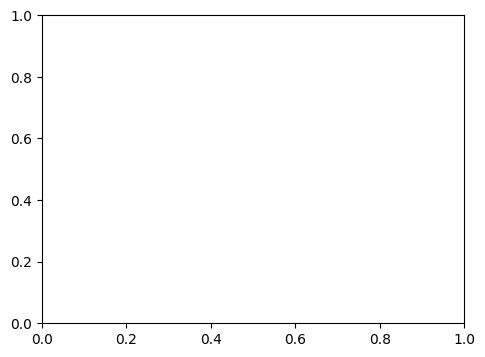

In [9]:
# Plot training progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Test the model
model.eval()
all_predictions = []
all_labels = []
test_correct = 0
test_total = 0

print("Testing the model...\n")

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(pixel_values=images)
        _, predicted = torch.max(outputs.logits, 1)
        
        # Store predictions and labels
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Calculate accuracy
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
print(f"\nTest Accuracy: {test_accuracy:.2f}%")

Testing the model...



Testing: 100%|██████████| 625/625 [06:31<00:00,  1.59it/s]


Test Accuracy: 99.02%



Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99     10000
        REAL       0.99      0.99      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000


Confusion Matrix:
[[9887  113]
 [  84 9916]]


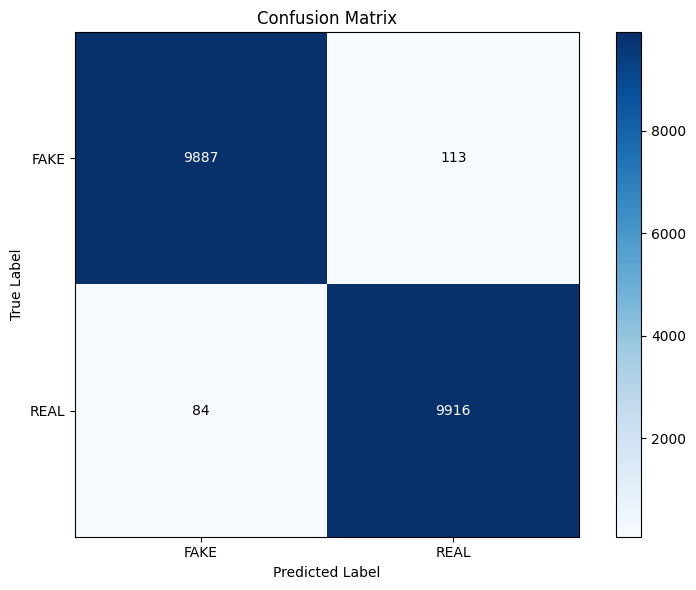

In [11]:
# Detailed classification report
print("\nClassification Report:")
print("="*60)
target_names = ['FAKE', 'REAL']
print(classification_report(all_labels, all_predictions, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names)
plt.yticks(tick_marks, target_names)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model
model_save_path = './trained_vit_model'
os.makedirs(model_save_path, exist_ok=True)

model.save_pretrained(model_save_path)
processor.save_pretrained(model_save_path)

print(f"Model saved to: {os.path.abspath(model_save_path)}")

## Sample Predictions

Let's visualize some sample predictions from the test set.

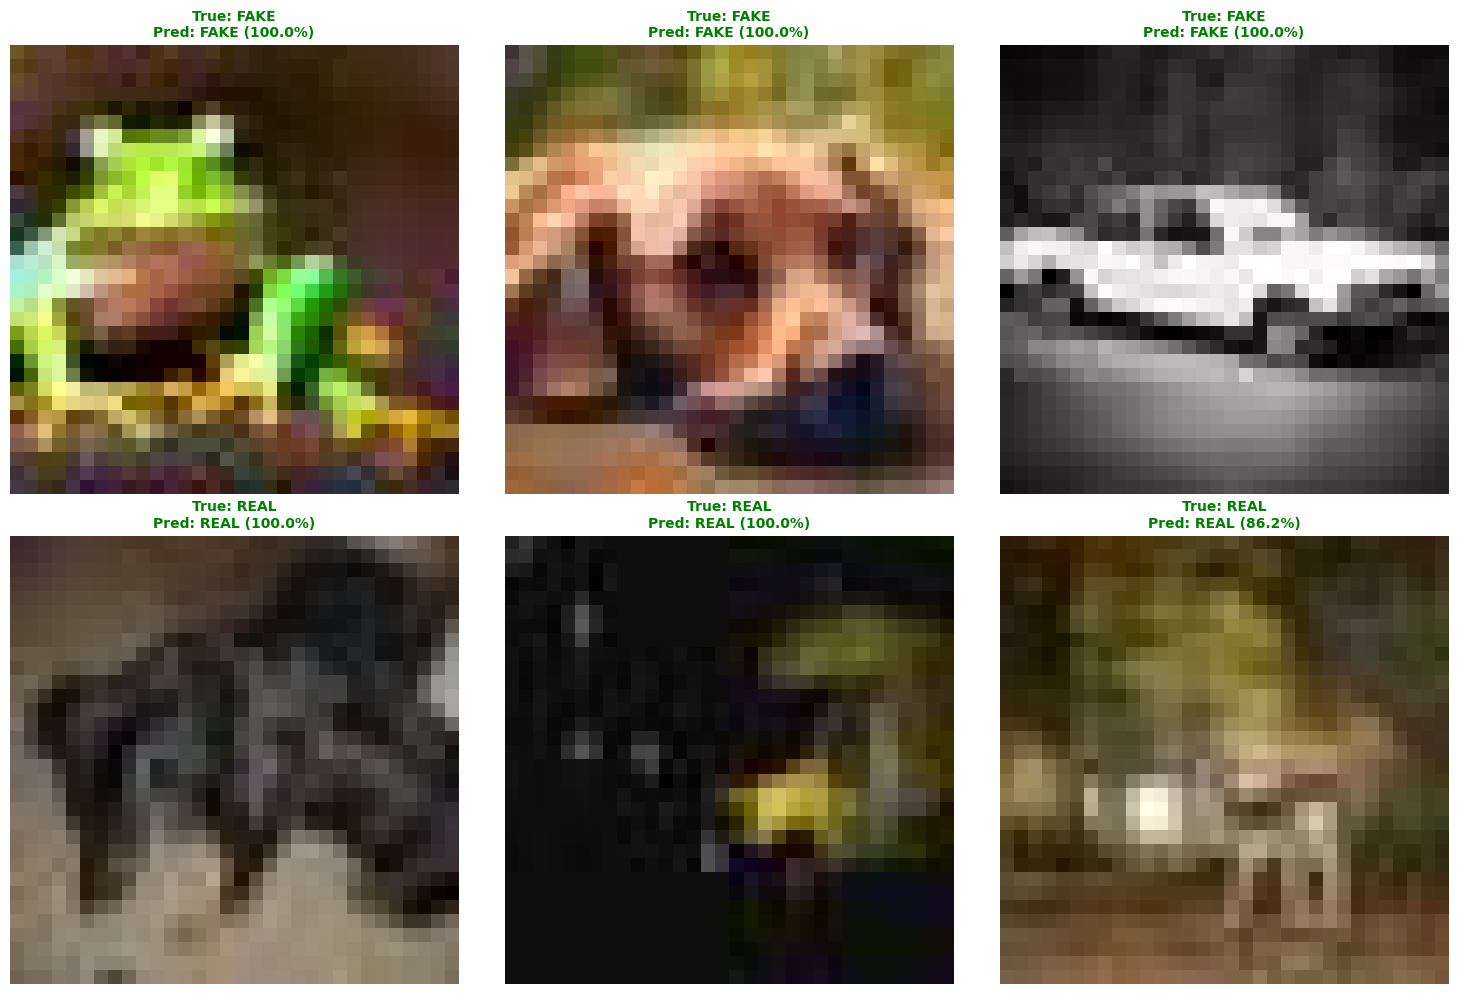

In [12]:
# Visualize sample predictions
from PIL import Image

def predict_image(image_path):
    """Predict if an image is real or fake"""
    image = Image.open(image_path).convert('RGB')
    inputs = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(pixel_values=inputs)
        _, predicted = torch.max(outputs.logits, 1)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=1)
    
    pred_label = target_names[predicted.item()]
    confidence = probabilities[0][predicted.item()].item() * 100
    
    return image, pred_label, confidence

# Get sample images
import random
sample_images = []

for category in ['FAKE', 'REAL']:
    category_path = os.path.join(test_dir, category)
    images = os.listdir(category_path)
    samples = random.sample(images, min(3, len(images)))
    for img in samples:
        sample_images.append((os.path.join(category_path, img), category))

# Display predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (img_path, true_label) in enumerate(sample_images):
    image, pred_label, confidence = predict_image(img_path)
    
    axes[idx].imshow(image)
    axes[idx].axis('off')
    
    color = 'green' if pred_label == true_label else 'red'
    title = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
    axes[idx].set_title(title, color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Additional Visualizations

More detailed performance analysis graphs.

Getting probabilities: 100%|██████████| 625/625 [02:15<00:00,  4.62it/s]


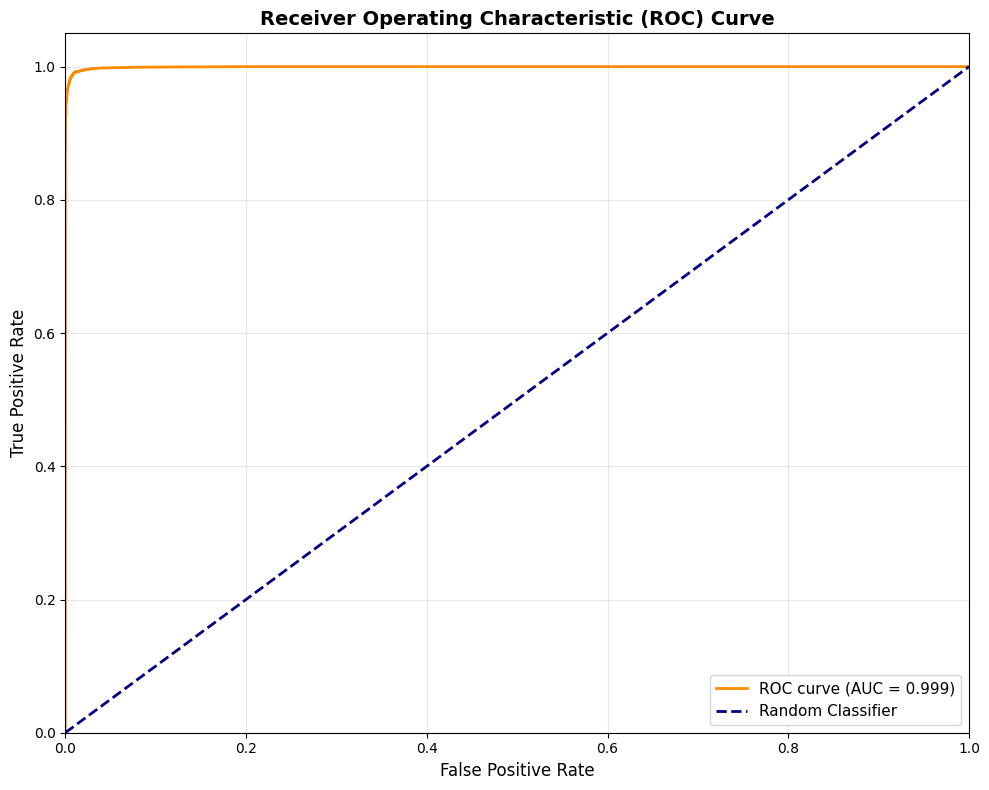

AUC Score: 0.9995


In [13]:
# ROC Curve and AUC Score
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for ROC curve
model.eval()
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Getting probabilities"):
        images = images.to(device)
        outputs = model(pixel_values=images)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=1)
        all_probs.extend(probabilities.cpu().numpy())

all_probs = np.array(all_probs)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

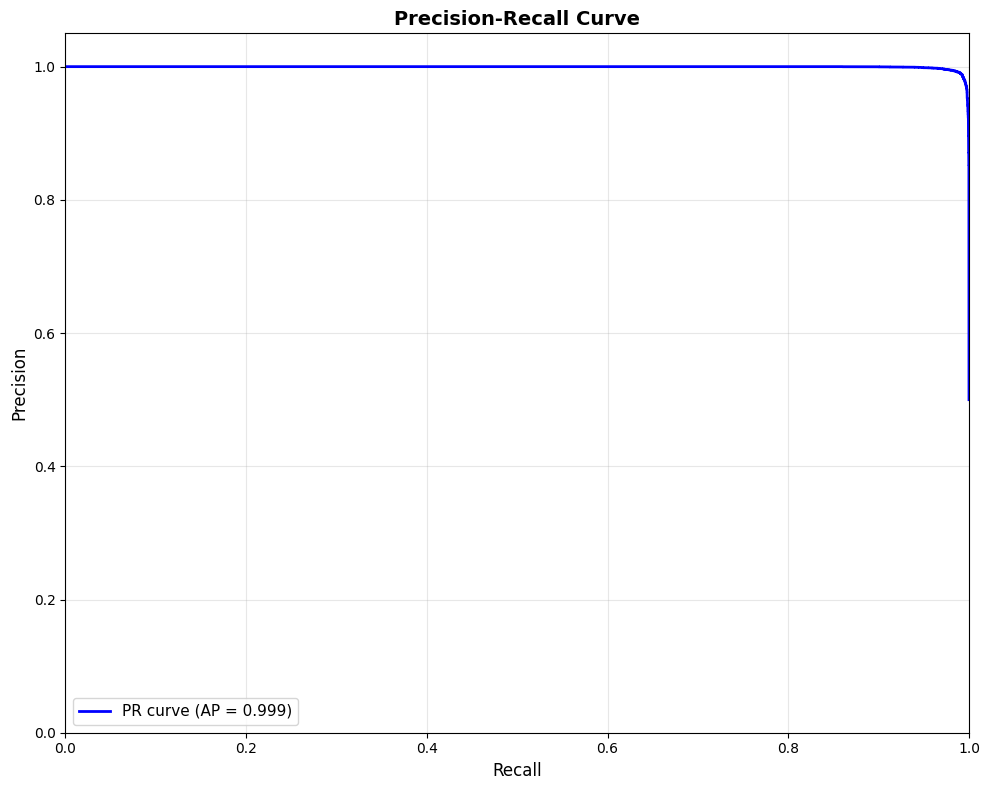

Average Precision Score: 0.9995


In [14]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_labels, all_probs[:, 1])
avg_precision = average_precision_score(all_labels, all_probs[:, 1])

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")

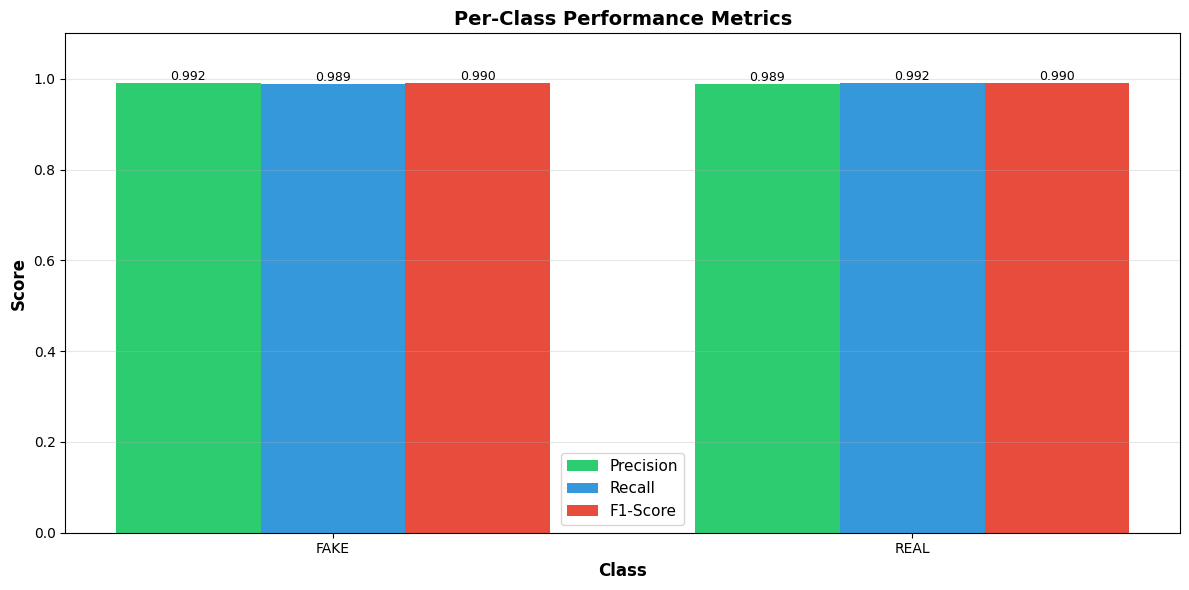

In [15]:
# Per-Class Performance Metrics Bar Chart
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate per-class metrics
precision_per_class = precision_score(all_labels, all_predictions, average=None)
recall_per_class = recall_score(all_labels, all_predictions, average=None)
f1_per_class = f1_score(all_labels, all_predictions, average=None)

# Create bar chart
x = np.arange(len(target_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='#2ecc71')
bars2 = ax.bar(x, recall_per_class, width, label='Recall', color='#3498db')
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-Score', color='#e74c3c')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

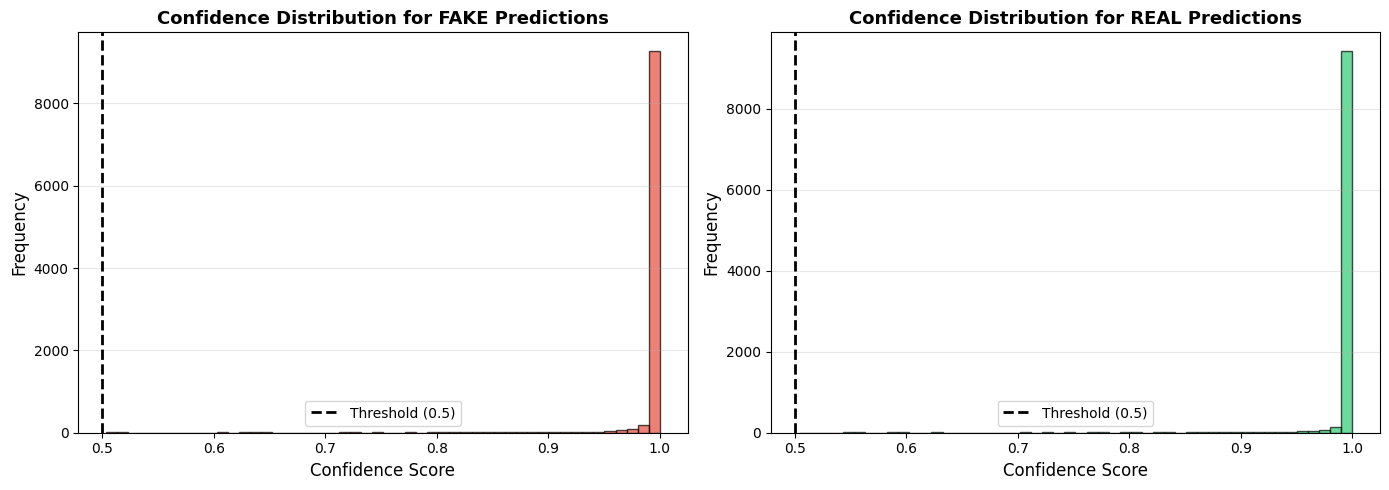

Average confidence for FAKE predictions: 0.9916
Average confidence for REAL predictions: 0.9923


In [16]:
# Prediction Confidence Distribution
plt.figure(figsize=(14, 5))

# Get confidence for each prediction
confidences_fake = [all_probs[i][0] for i in range(len(all_labels)) if all_predictions[i] == 0]
confidences_real = [all_probs[i][1] for i in range(len(all_labels)) if all_predictions[i] == 1]

# Subplot 1: Histogram for FAKE predictions
plt.subplot(1, 2, 1)
plt.hist(confidences_fake, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Confidence Distribution for FAKE Predictions', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
plt.legend()

# Subplot 2: Histogram for REAL predictions
plt.subplot(1, 2, 2)
plt.hist(confidences_real, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Confidence Distribution for REAL Predictions', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Average confidence for FAKE predictions: {np.mean(confidences_fake):.4f}")
print(f"Average confidence for REAL predictions: {np.mean(confidences_real):.4f}")

ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

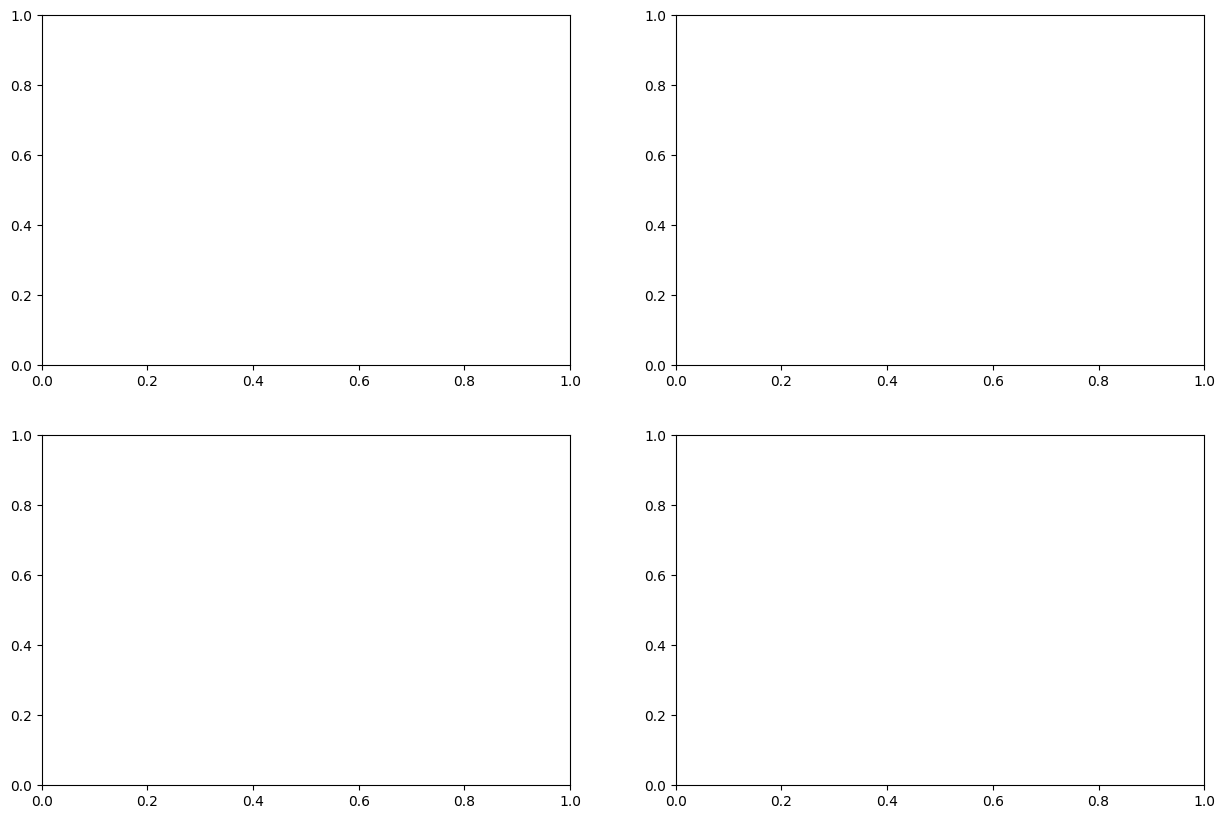

In [17]:
# Training Metrics Combined View
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curve
axes[0, 0].plot(range(1, num_epochs+1), train_losses, marker='o', color='#e74c3c', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Training Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, num_epochs+1))

# Accuracy curve
axes[0, 1].plot(range(1, num_epochs+1), train_accuracies, marker='s', color='#2ecc71', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 1].set_title('Training Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(1, num_epochs+1))

# Loss improvement per epoch
loss_improvements = [0] + [train_losses[i-1] - train_losses[i] for i in range(1, len(train_losses))]
axes[1, 0].bar(range(1, num_epochs+1), loss_improvements, color='#3498db', edgecolor='black')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Loss Improvement', fontsize=11)
axes[1, 0].set_title('Loss Improvement Per Epoch', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].set_xticks(range(1, num_epochs+1))

# Accuracy improvement per epoch
acc_improvements = [0] + [train_accuracies[i] - train_accuracies[i-1] for i in range(1, len(train_accuracies))]
axes[1, 1].bar(range(1, num_epochs+1), acc_improvements, color='#9b59b6', edgecolor='black')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Accuracy Improvement (%)', fontsize=11)
axes[1, 1].set_title('Accuracy Improvement Per Epoch', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].set_xticks(range(1, num_epochs+1))

plt.tight_layout()
plt.show()

Total misclassified images: 197
Misclassification rate: 0.98%



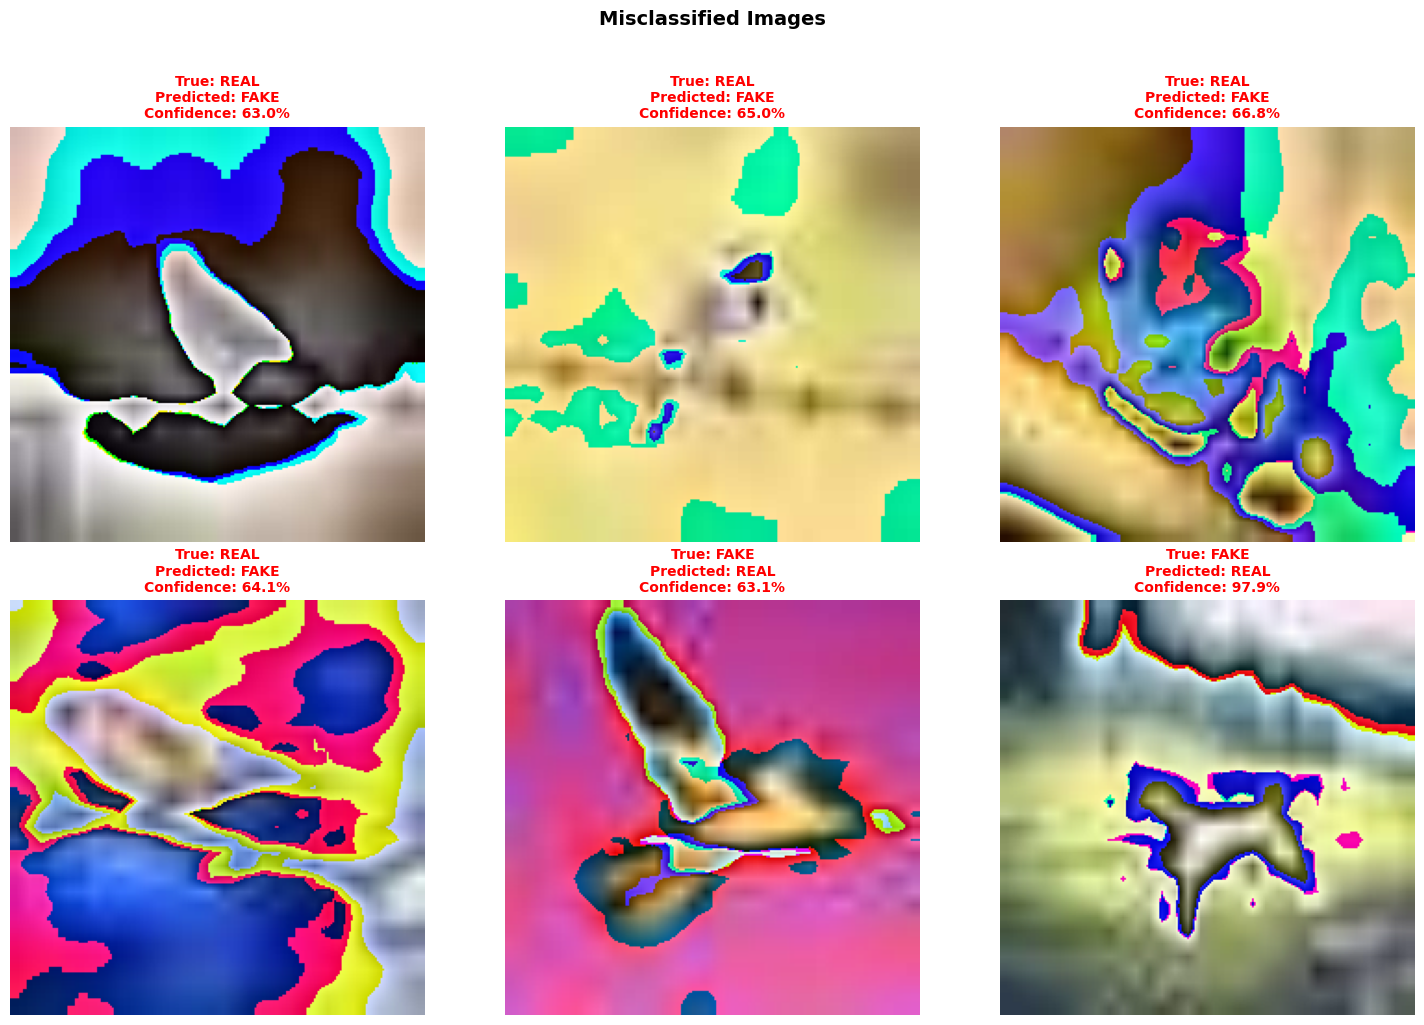

In [18]:
# Misclassified Images Analysis
from PIL import Image

# Find misclassified images
misclassified_indices = [i for i in range(len(all_labels)) if all_labels[i] != all_predictions[i]]

if len(misclassified_indices) > 0:
    print(f"Total misclassified images: {len(misclassified_indices)}")
    print(f"Misclassification rate: {100 * len(misclassified_indices) / len(all_labels):.2f}%\n")
    
    # Get sample misclassified images
    num_samples = min(6, len(misclassified_indices))
    sample_indices = np.random.choice(misclassified_indices, num_samples, replace=False)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    # Get images from test dataset
    test_dataset_list = list(test_dataset)
    
    for idx, mis_idx in enumerate(sample_indices):
        # Get image and labels
        image_tensor, true_label = test_dataset_list[mis_idx]
        pred_label = all_predictions[mis_idx]
        confidence = all_probs[mis_idx][pred_label] * 100
        
        # Convert tensor to PIL image
        image = transforms.ToPILImage()(image_tensor)
        
        axes[idx].imshow(image)
        axes[idx].axis('off')
        
        title = f"True: {target_names[true_label]}\nPredicted: {target_names[pred_label]}\nConfidence: {confidence:.1f}%"
        axes[idx].set_title(title, color='red', fontsize=10, fontweight='bold')
    
    plt.suptitle('Misclassified Images', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images! Perfect accuracy!")

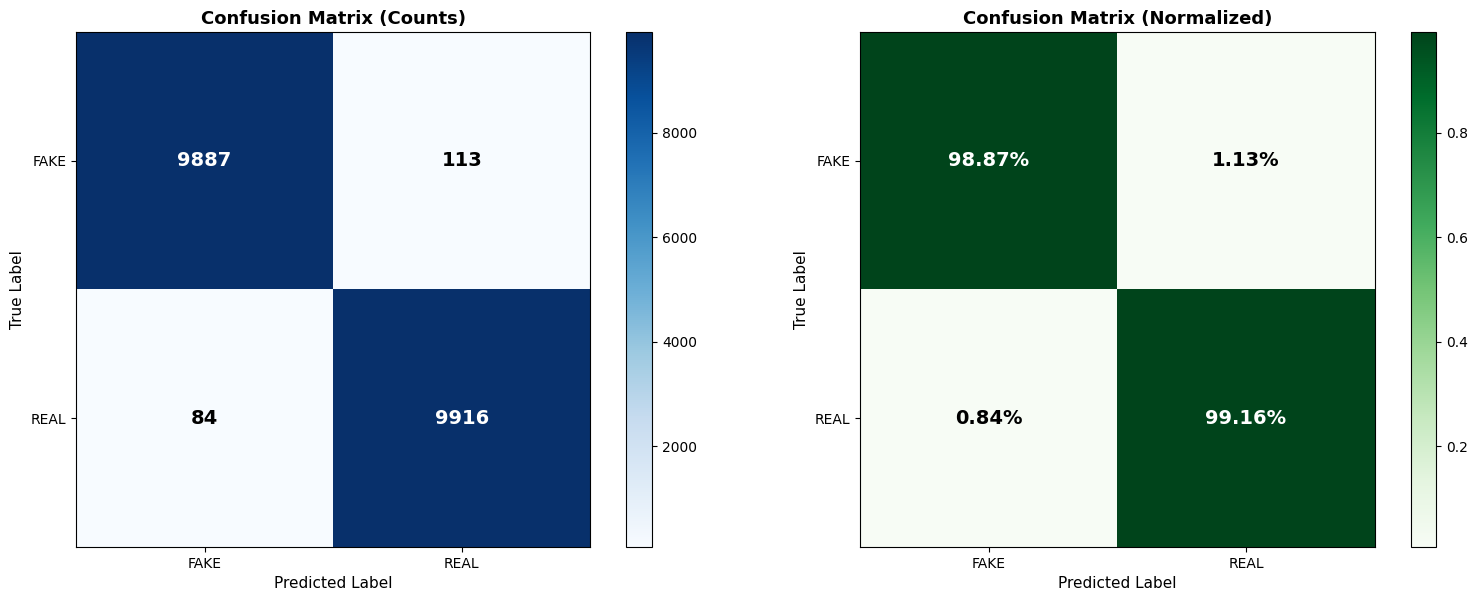

In [19]:
# Confusion Matrix Normalized (Percentage)
from sklearn.metrics import confusion_matrix

cm_normalized = confusion_matrix(all_labels, all_predictions, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original confusion matrix (counts)
im1 = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
tick_marks = np.arange(len(target_names))
axes[0].set_xticks(tick_marks)
axes[0].set_yticks(tick_marks)
axes[0].set_xticklabels(target_names)
axes[0].set_yticklabels(target_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')

axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
plt.colorbar(im1, ax=axes[0])

# Normalized confusion matrix (percentages)
im2 = axes[1].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Greens)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(target_names)
axes[1].set_yticklabels(target_names)

thresh = cm_normalized.max() / 2.
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        axes[1].text(j, i, f'{cm_normalized[i, j]:.2%}',
                    ha="center", va="center",
                    color="white" if cm_normalized[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')

axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

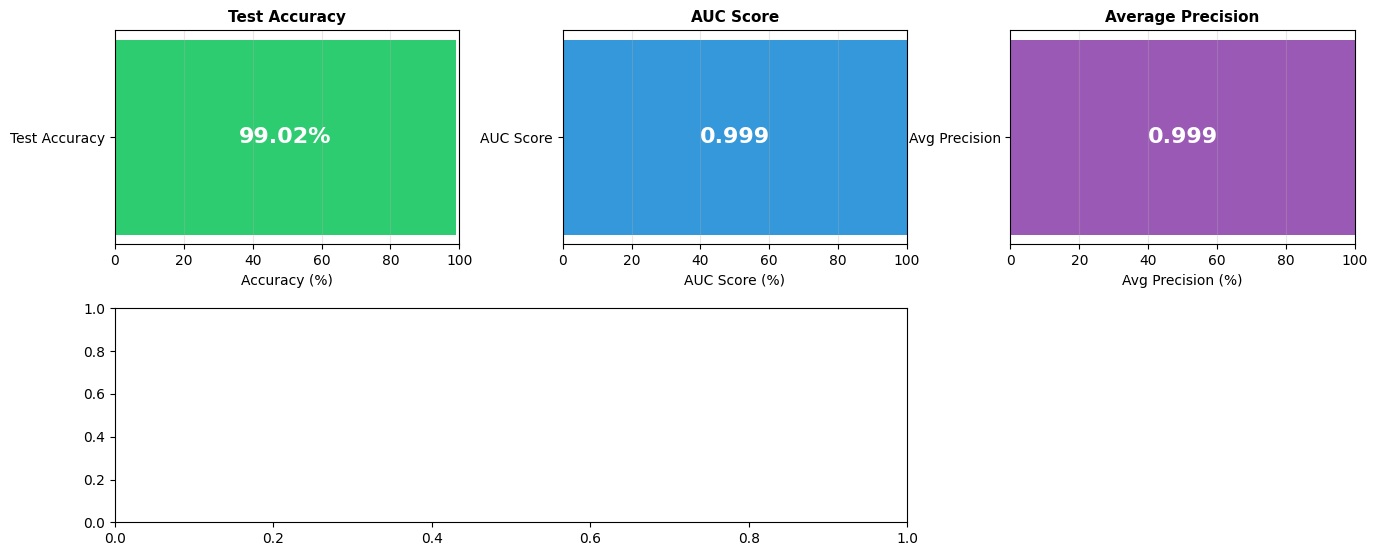

In [20]:
# Model Performance Summary Dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Overall Accuracy Gauge
ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(['Test Accuracy'], [test_accuracy], color='#2ecc71', height=0.5)
ax1.set_xlim([0, 100])
ax1.set_xlabel('Accuracy (%)', fontsize=10)
ax1.set_title('Test Accuracy', fontsize=11, fontweight='bold')
ax1.text(test_accuracy/2, 0, f'{test_accuracy:.2f}%', ha='center', va='center', 
         fontsize=16, fontweight='bold', color='white')
ax1.grid(axis='x', alpha=0.3)

# 2. AUC Score Gauge
ax2 = fig.add_subplot(gs[0, 1])
ax2.barh(['AUC Score'], [roc_auc * 100], color='#3498db', height=0.5)
ax2.set_xlim([0, 100])
ax2.set_xlabel('AUC Score (%)', fontsize=10)
ax2.set_title('AUC Score', fontsize=11, fontweight='bold')
ax2.text(roc_auc * 50, 0, f'{roc_auc:.3f}', ha='center', va='center', 
         fontsize=16, fontweight='bold', color='white')
ax2.grid(axis='x', alpha=0.3)

# 3. Average Precision Gauge
ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(['Avg Precision'], [avg_precision * 100], color='#9b59b6', height=0.5)
ax3.set_xlim([0, 100])
ax3.set_xlabel('Avg Precision (%)', fontsize=10)
ax3.set_title('Average Precision', fontsize=11, fontweight='bold')
ax3.text(avg_precision * 50, 0, f'{avg_precision:.3f}', ha='center', va='center', 
         fontsize=16, fontweight='bold', color='white')
ax3.grid(axis='x', alpha=0.3)

# 4. Training Loss
ax4 = fig.add_subplot(gs[1, :2])
ax4.plot(range(1, num_epochs+1), train_losses, marker='o', color='#e74c3c', linewidth=2.5, markersize=10)
ax4.set_xlabel('Epoch', fontsize=10)
ax4.set_ylabel('Loss', fontsize=10)
ax4.set_title('Training Loss Progress', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(1, num_epochs+1))

# 5. Training Accuracy
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(range(1, num_epochs+1), train_accuracies, marker='s', color='#2ecc71', linewidth=2.5, markersize=10)
ax5.set_xlabel('Epoch', fontsize=10)
ax5.set_ylabel('Accuracy (%)', fontsize=10)
ax5.set_title('Training Accuracy Progress', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.set_xticks(range(1, num_epochs+1))

# 6. Per-Class F1 Scores
ax6 = fig.add_subplot(gs[1:, 2])
colors = ['#e74c3c', '#2ecc71']
bars = ax6.barh(target_names, f1_per_class, color=colors, edgecolor='black', linewidth=1.5)
ax6.set_xlim([0, 1.1])
ax6.set_xlabel('F1-Score', fontsize=10)
ax6.set_title('Per-Class F1-Scores', fontsize=11, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars, f1_per_class)):
    ax6.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Model Performance Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Test Accuracy:        {test_accuracy:.2f}%")
print(f"ROC AUC Score:        {roc_auc:.4f}")
print(f"Average Precision:    {avg_precision:.4f}")
print(f"Total Parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Training Epochs:      {num_epochs}")
print(f"Final Training Loss:  {train_losses[-1]:.4f}")
print(f"Final Training Acc:   {train_accuracies[-1]:.2f}%")
print(f"Misclassified:        {len(misclassified_indices)} / {len(all_labels)}")
print("="*60)

## Predict on Random Image from Root Directory

Load the saved model and predict on a random image.

In [21]:
# Load the saved model
import torch
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
import os

# Path to saved model
model_save_path = './trained_vit_model'

# Load model and processor
print("Loading saved model...")
loaded_model = ViTForImageClassification.from_pretrained(model_save_path)
loaded_processor = ViTImageProcessor.from_pretrained(model_save_path)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model = loaded_model.to(device)
loaded_model.eval()

print(f"Model loaded successfully from: {os.path.abspath(model_save_path)}")
print(f"Using device: {device}")

Loading saved model...
Model loaded successfully from: c:\Coding\AI_detect\trained_vit_model
Using device: cuda


In [47]:
# Input image filename
# Enter the name of the image file in the root directory
image_filename = input("Enter the image filename (e.g., 'test_image.png'): ")

# Construct full path
image_path = os.path.join('.', image_filename)

# Check if file exists
if os.path.exists(image_path):
    print(f"✓ Image found: {os.path.abspath(image_path)}")
else:
    print(f"✗ Image not found: {os.path.abspath(image_path)}")
    print(f"Please make sure the file '{image_filename}' exists in the root directory: {os.path.abspath('.')}")

✓ Image found: c:\Coding\AI_detect\5.jpg



Processing image: 5.jpg


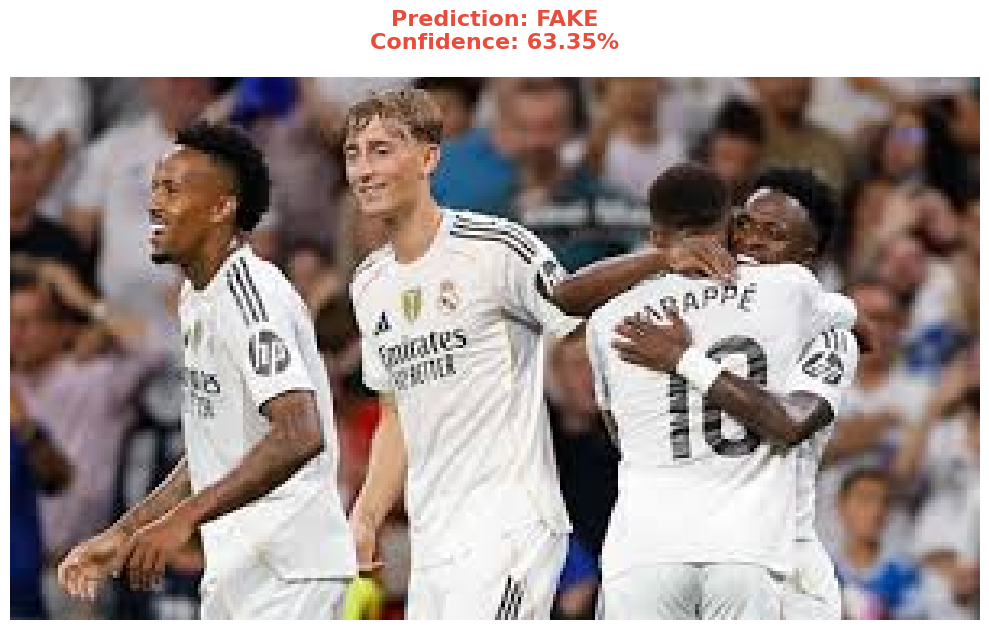


PREDICTION RESULTS
Image: 5.jpg
Prediction: FAKE
Confidence: 63.35%

Class Probabilities:
  FAKE: 63.35%
  REAL: 36.65%


In [48]:
# Predict on the specified image
import matplotlib.pyplot as plt
from torchvision import transforms

if os.path.exists(image_path):
    print(f"\nProcessing image: {image_filename}")
    
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    
    # Create transform matching the training setup
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=loaded_processor.image_mean, std=loaded_processor.image_std)
    ])
    
    # Transform image
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Make prediction
    with torch.no_grad():
        outputs = loaded_model(pixel_values=image_tensor)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item() * 100
    
    # Get class names
    class_names = list(loaded_model.config.id2label.values())
    predicted_label = class_names[predicted_class]
    
    # Display results
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image)
    ax.axis('off')
    
    # Set title color based on prediction
    color = '#2ecc71' if predicted_label == 'REAL' else '#e74c3c'
    title = f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%"
    ax.set_title(title, fontsize=16, fontweight='bold', color=color, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print("\n" + "="*50)
    print("PREDICTION RESULTS")
    print("="*50)
    print(f"Image: {image_filename}")
    print(f"Prediction: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")
    print("\nClass Probabilities:")
    for i, class_name in enumerate(class_names):
        prob = probabilities[0][i].item() * 100
        print(f"  {class_name}: {prob:.2f}%")
    print("="*50)
else:
    print(f"\n✗ Cannot make prediction - image file '{image_filename}' not found!")
    print(f"Please check the filename and make sure the file exists in: {os.path.abspath('.')}")